# Bank Customer Churn Prediction

## Notebook 4: Model Explainability and Final Analysis

This notebook explains the predictions made by the final churn model.

The analysis includes:
- Feature importance
- SHAP analysis
- Partial Dependence Plots
- Individual customer explanations
- High-risk customer analysis
- Business-level observations
- Model limitations
- Final conclusions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.inspection import PartialDependenceDisplay

import warnings
warnings.filterwarnings("ignore")

In [2]:
X_train = pd.read_csv("X_train_raw.csv")
X_test = pd.read_csv("X_test_raw.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (8000, 15)
Testing data : (2000, 15)


In [3]:
final_model = joblib.load("final_model.pkl")

print("Final model loaded.")
print(final_model)

Final model loaded.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                              

In [4]:
model = final_model.named_steps["model"]
preprocessor = final_model.named_steps["preprocessor"]

print("Model used:")
print(model)

Model used:
GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)


In [5]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 18
['num__Year' 'num__CreditScore' 'num__Age' 'num__Tenure' 'num__Balance'
 'num__NumOfProducts' 'num__HasCrCard' 'num__IsActiveMember'
 'num__EstimatedSalary' 'num__BalanceSalaryRatio' 'num__ProductDensity'
 'num__EngagementProductInteraction' 'num__AgeTenureInteraction'
 'cat__Geography_France' 'cat__Geography_Germany' 'cat__Geography_Spain'
 'cat__Gender_Female' 'cat__Gender_Male']


In [6]:
X_test_processed = preprocessor.transform(X_test)

X_train_processed = preprocessor.transform(X_train)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data :", X_test_processed.shape)

Processed training data: (8000, 18)
Processed testing data : (2000, 18)


In [7]:
X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed.head()

,num__Year,num__CreditScore,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__EstimatedSalary,num__BalanceSalaryRatio,num__ProductDensity,num__EngagementProductInteraction,num__AgeTenureInteraction,cat__Geography_France,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Female,cat__Gender_Male
0,0.0,-0.680735,-0.279932,0.684723,-1.226059,0.808830,0.641042,-1.030206,-0.095021,-0.036843,-0.346241,-0.908608,0.440039,1.0,0.0,0.0,0.0,1.0
1,0.0,-1.301915,-0.564935,-0.350971,0.877113,0.808830,-1.559960,-1.030206,-0.778941,-0.015525,0.102065,-0.908608,-0.491022,0.0,1.0,0.0,0.0,1.0
2,0.0,-0.970619,0.100072,-0.350971,-1.226059,0.808830,-1.559960,0.970680,0.099469,-0.036843,0.102065,1.390574,-0.273775,0.0,0.0,1.0,1.0,0.0
3,0.0,-0.121674,-0.469934,-0.005739,1.011458,0.808830,-1.559960,-1.030206,-1.147374,-0.000054,-0.097182,-0.908608,-0.196186,0.0,0.0,1.0,0.0,1.0
4,0.0,-0.111321,-0.469934,-0.696202,0.023204,-0.910256,0.641042,0.970680,1.200283,-0.032705,-0.346241,0.240983,-0.723788,0.0,0.0,1.0,1.0,0.0


In [8]:
if hasattr(model, "feature_importances_"):

    importance = model.feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

else:

    importance = np.abs(model.coef_[0])

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
2,num__Age,0.389502
5,num__NumOfProducts,0.290745
11,num__EngagementProductInteraction,0.078902
4,num__Balance,0.062582
14,cat__Geography_Germany,0.050792
7,num__IsActiveMember,0.043311
9,num__BalanceSalaryRatio,0.024989
1,num__CreditScore,0.016018
8,num__EstimatedSalary,0.014378
12,num__AgeTenureInteraction,0.009436


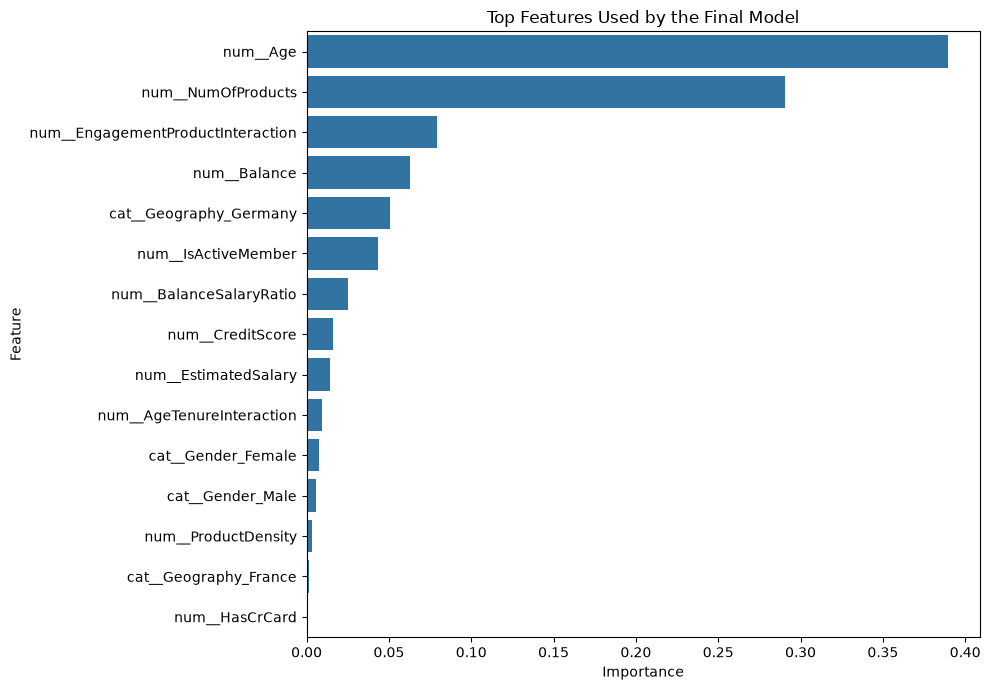

In [9]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Used by the Final Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [10]:
feature_importance

,Feature,Importance
2,num__Age,0.389502
5,num__NumOfProducts,0.290745
11,num__EngagementProductInteraction,0.078902
4,num__Balance,0.062582
14,cat__Geography_Germany,0.050792
7,num__IsActiveMember,0.043311
9,num__BalanceSalaryRatio,0.024989
1,num__CreditScore,0.016018
8,num__EstimatedSalary,0.014378
12,num__AgeTenureInteraction,0.009436


In [12]:
feature_importance.to_csv("feature_importance.csv",index=False)

In [13]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_test_processed
)

print("SHAP values created.")

SHAP values created.


In [14]:
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP shape:", np.array(shap_values).shape)

SHAP shape: (2000, 18)


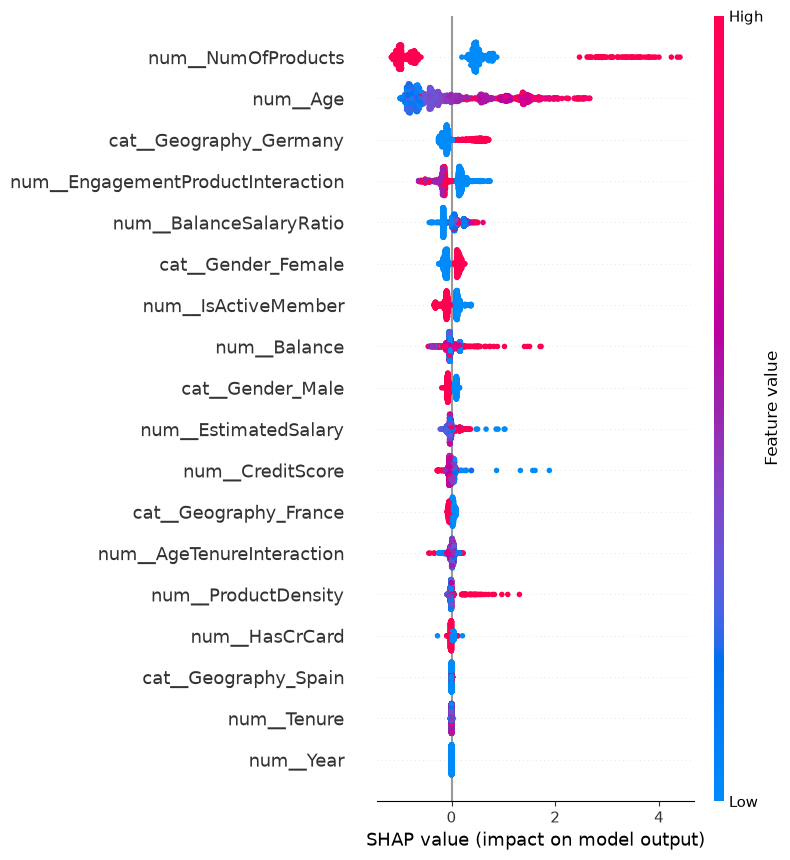

In [15]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    show=False
)

plt.tight_layout()
plt.show()

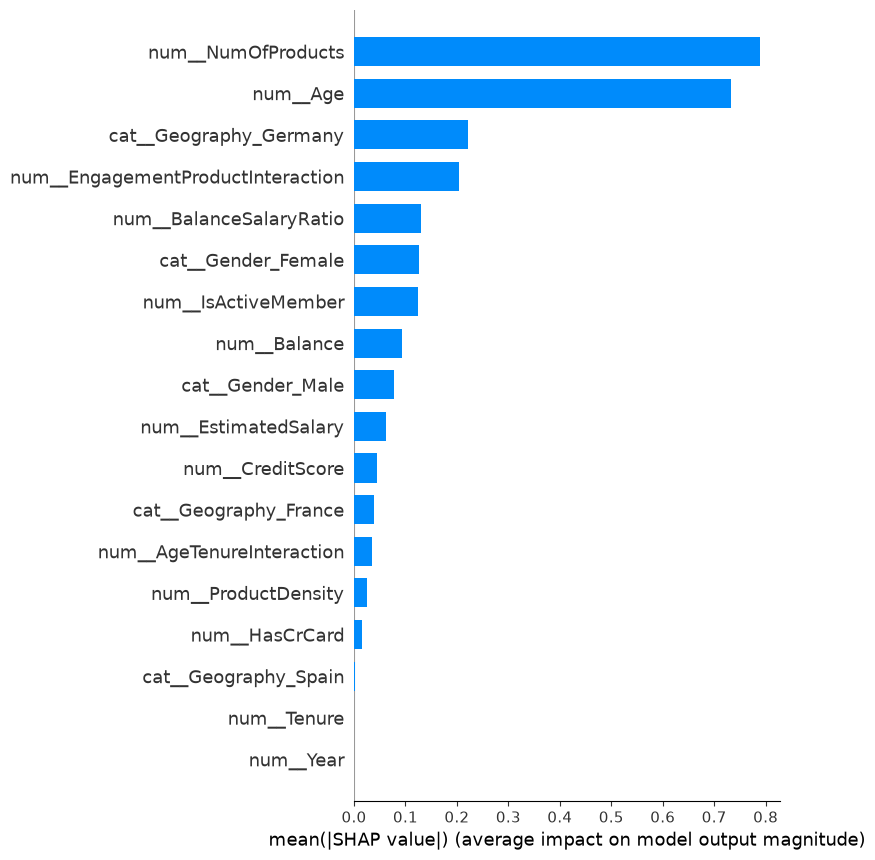

In [16]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

In [17]:
shap_importance = pd.DataFrame({
    "Feature": X_test_processed.columns,
    "MeanAbsoluteSHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "MeanAbsoluteSHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,MeanAbsoluteSHAP
5,num__NumOfProducts,0.788404
2,num__Age,0.732373
14,cat__Geography_Germany,0.220756
11,num__EngagementProductInteraction,0.204893
9,num__BalanceSalaryRatio,0.131012
16,cat__Gender_Female,0.126277
7,num__IsActiveMember,0.125277
4,num__Balance,0.092287
17,cat__Gender_Male,0.077997
8,num__EstimatedSalary,0.061638


In [18]:
shap_importance.to_csv("shap_importance.csv",index=False)

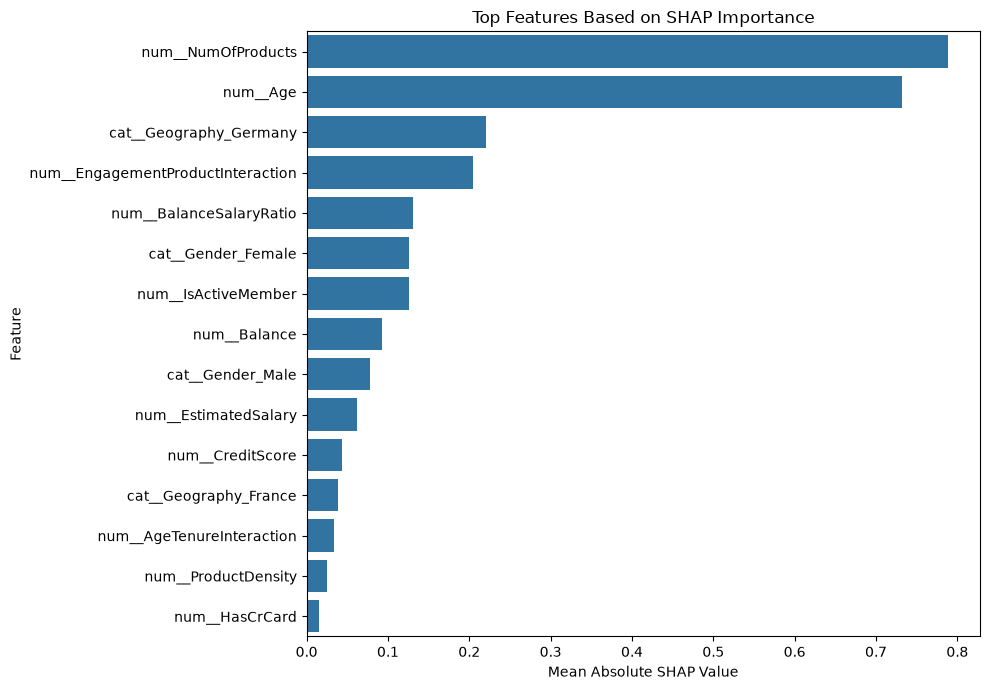

In [19]:
top_shap = shap_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_shap,
    x="MeanAbsoluteSHAP",
    y="Feature"
)

plt.title("Top Features Based on SHAP Importance")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [24]:
pdp_features = [
    "Year",
    "Age",
    "CreditScore",
    "Balance",
    "NumOfProducts",
    "Tenure"
]

print(pdp_features)

['Year', 'Age', 'CreditScore', 'Balance', 'NumOfProducts', 'Tenure']


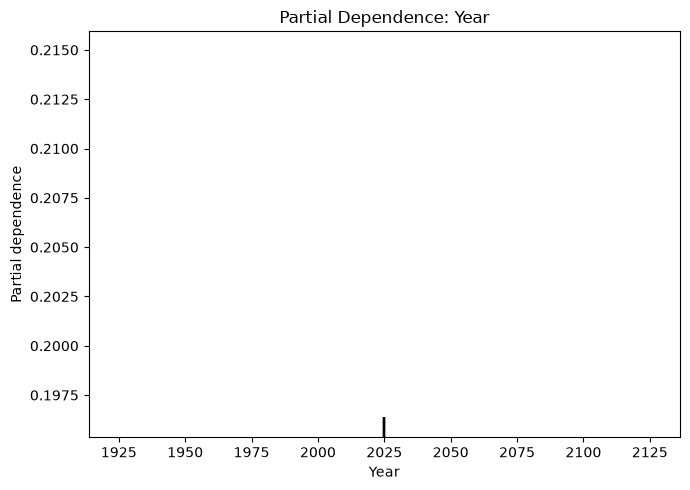

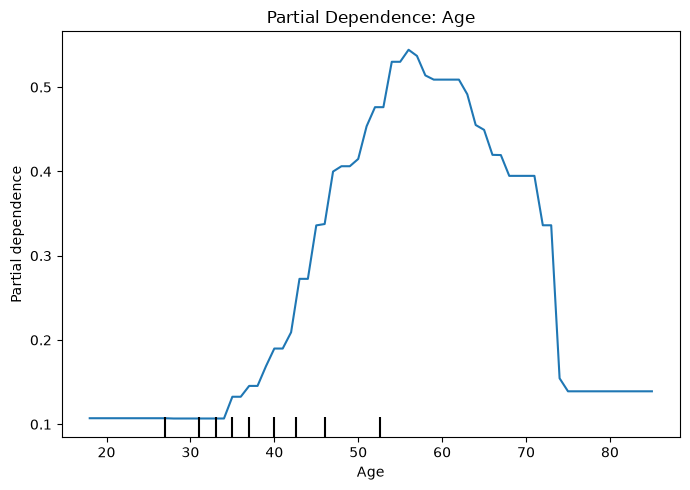

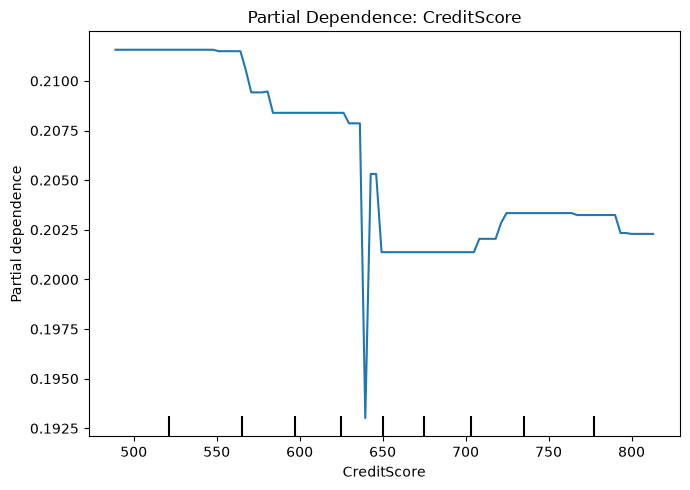

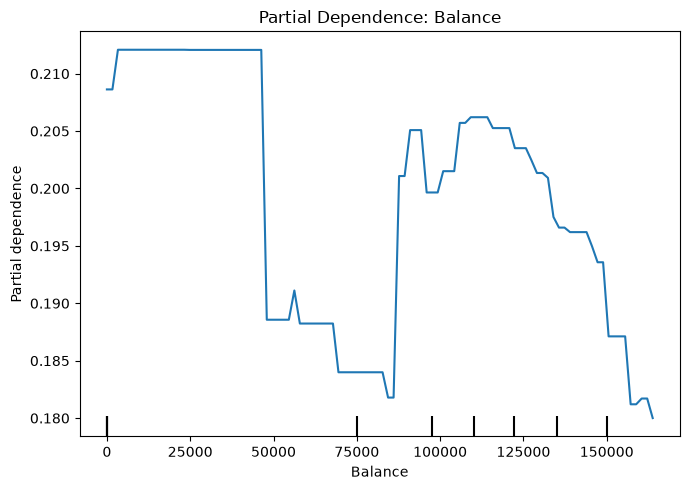

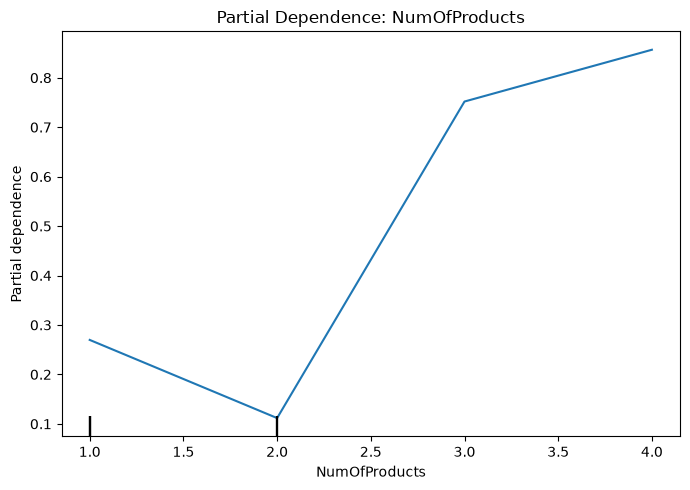

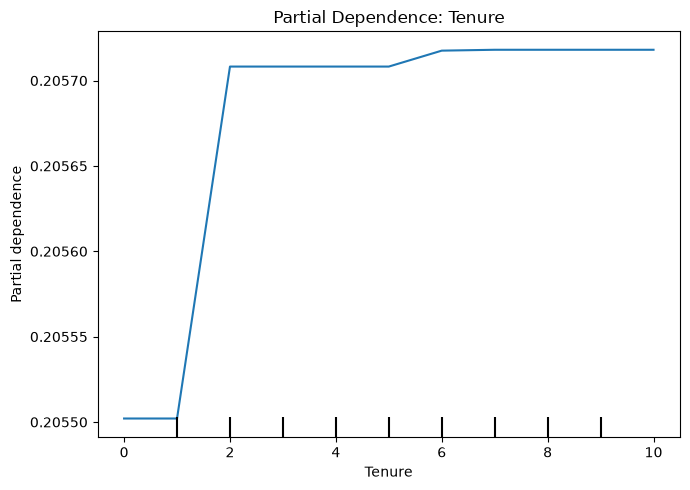

In [28]:
X_test_pdp = X_test.copy()

for feature in pdp_features:
    X_test_pdp[feature] = X_test_pdp[feature].astype(float)

for feature in pdp_features:

    fig, ax = plt.subplots(figsize=(7, 5))

    PartialDependenceDisplay.from_estimator(
        final_model,
        X_test_pdp,
        [feature],
        ax=ax
    )

    plt.title("Partial Dependence: " + feature)
    plt.tight_layout()
    plt.show()

In [29]:
print("Final model:")
print(final_model)

print("\nTest data shape:", X_test.shape)
print("Test columns:")
print(X_test.columns.tolist())

Final model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'BalanceSalaryRatio',
                                                   'ProductDensity',
                                     

In [30]:
model = final_model.named_steps["model"]
preprocessor = final_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importance = model.feature_importances_

elif hasattr(model, "coef_"):
    importance = np.abs(model.coef_[0])

else:
    importance = None

if importance is not None:

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    feature_importance = feature_importance.sort_values(
        "Importance",
        ascending=False
    )

    print(feature_importance.head(15))

                              Feature  Importance
2                            num__Age    0.389502
5                  num__NumOfProducts    0.290745
11  num__EngagementProductInteraction    0.078902
4                        num__Balance    0.062582
14             cat__Geography_Germany    0.050792
7                 num__IsActiveMember    0.043311
9             num__BalanceSalaryRatio    0.024989
1                    num__CreditScore    0.016018
8                num__EstimatedSalary    0.014378
12          num__AgeTenureInteraction    0.009436
16                 cat__Gender_Female    0.007615
17                   cat__Gender_Male    0.005627
10                num__ProductDensity    0.003130
13              cat__Geography_France    0.001596
6                      num__HasCrCard    0.001022


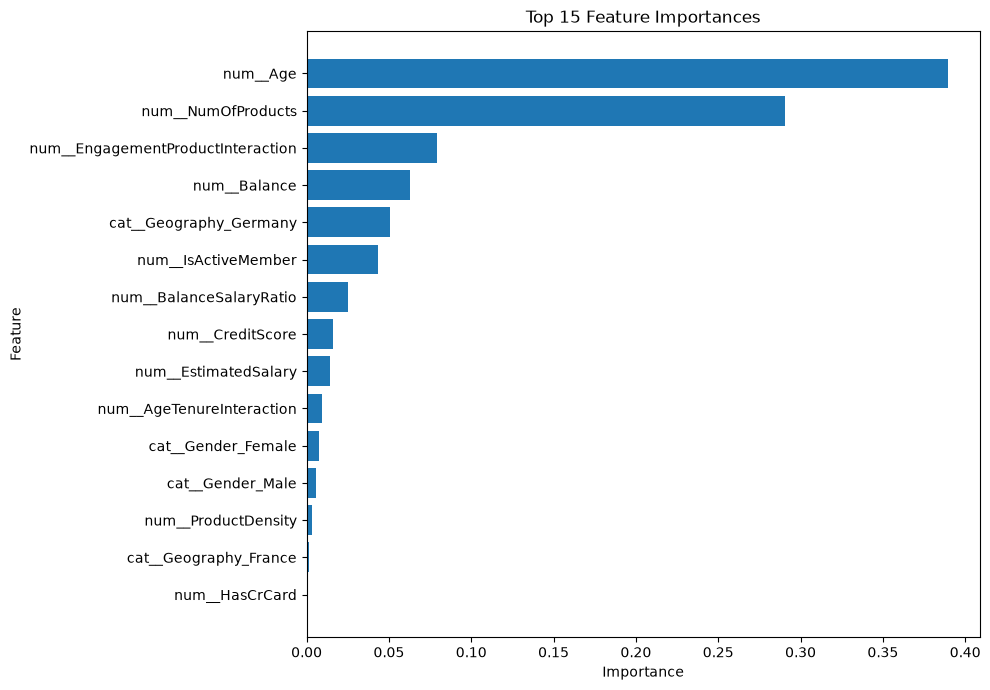

In [31]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.tight_layout()
plt.show()

In [33]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [34]:
X_test_processed = preprocessor.transform(X_test)

print("Processed test shape:", X_test_processed.shape)
print("Number of feature names:", len(feature_names))

Processed test shape: (2000, 18)
Number of feature names: 18


In [35]:
if hasattr(model, "feature_importances_"):

    explainer = shap.TreeExplainer(model)

elif hasattr(model, "coef_"):

    explainer = shap.LinearExplainer(
        model,
        X_test_processed
    )

else:

    explainer = shap.Explainer(
        model,
        X_test_processed
    )

shap_values = explainer(X_test_processed)

print("SHAP analysis completed.")

SHAP analysis completed.


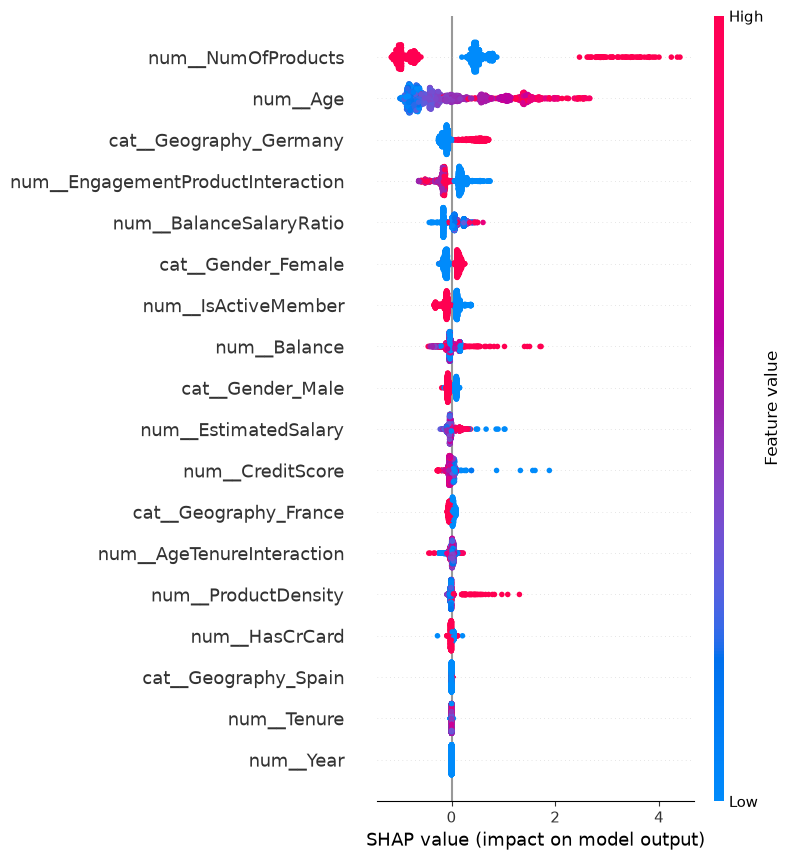

In [36]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()

In [37]:
if hasattr(shap_values, "values"):

    shap_array = shap_values.values

else:

    shap_array = shap_values

if len(shap_array.shape) == 3:
    shap_array = shap_array[:, :, 1]

mean_shap = np.abs(shap_array).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsoluteSHAP": mean_shap
})

shap_importance = shap_importance.sort_values(
    "MeanAbsoluteSHAP",
    ascending=False
)

print(shap_importance.head(15))

                              Feature  MeanAbsoluteSHAP
5                  num__NumOfProducts          0.788404
2                            num__Age          0.732373
14             cat__Geography_Germany          0.220756
11  num__EngagementProductInteraction          0.204893
9             num__BalanceSalaryRatio          0.131012
16                 cat__Gender_Female          0.126277
7                 num__IsActiveMember          0.125277
4                        num__Balance          0.092287
17                   cat__Gender_Male          0.077997
8                num__EstimatedSalary          0.061638
1                    num__CreditScore          0.043969
13              cat__Geography_France          0.038071
12          num__AgeTenureInteraction          0.034214
10                num__ProductDensity          0.025071
6                      num__HasCrCard          0.015700


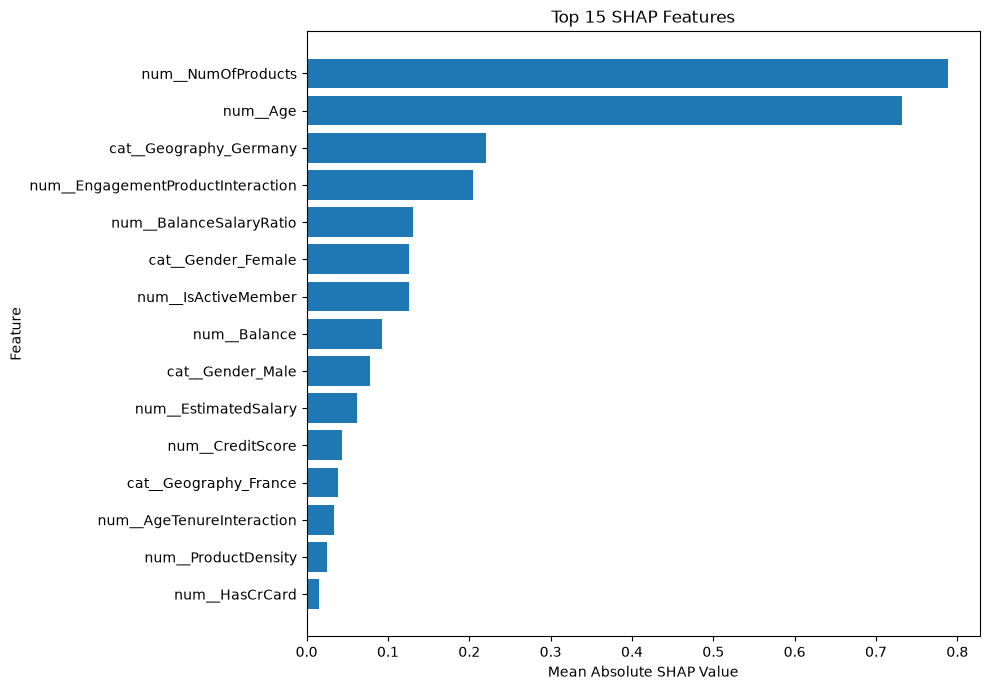

In [38]:
top_shap = shap_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_shap["Feature"][::-1],
    top_shap["MeanAbsoluteSHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 SHAP Features")

plt.tight_layout()
plt.show()

In [40]:
shap_importance.to_csv(
    "shap_importance.csv",
    index=False
)

print("SHAP importance saved.")

SHAP importance saved.


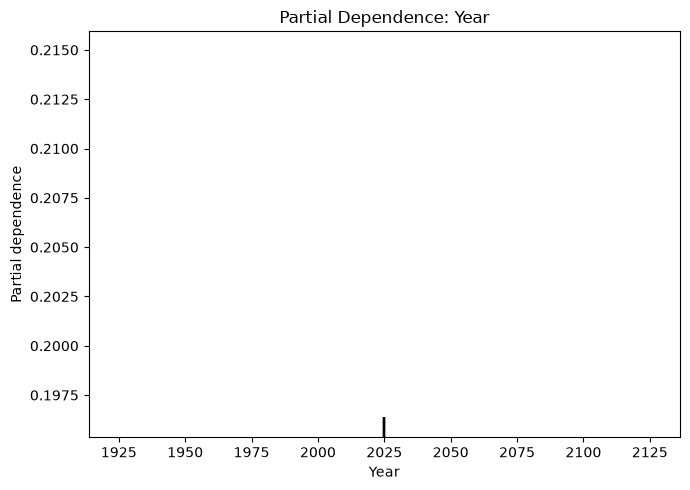

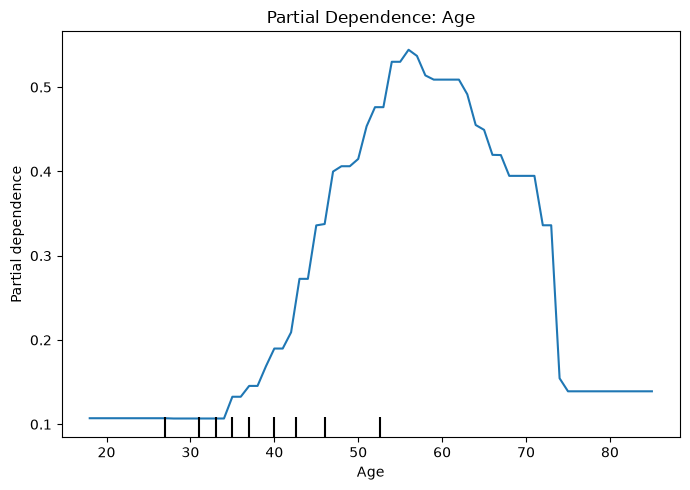

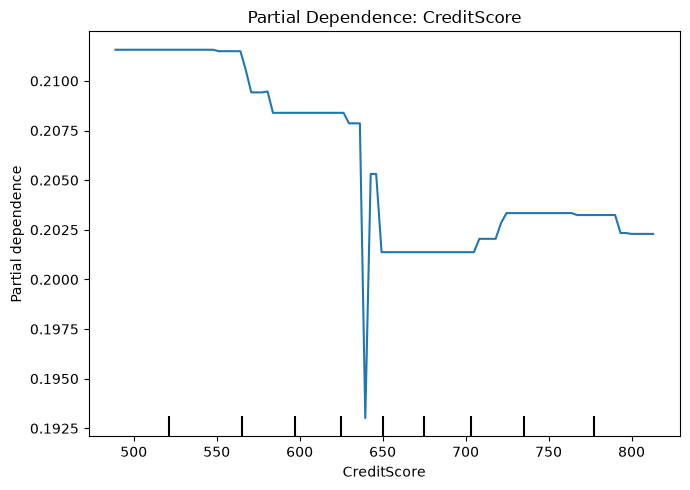

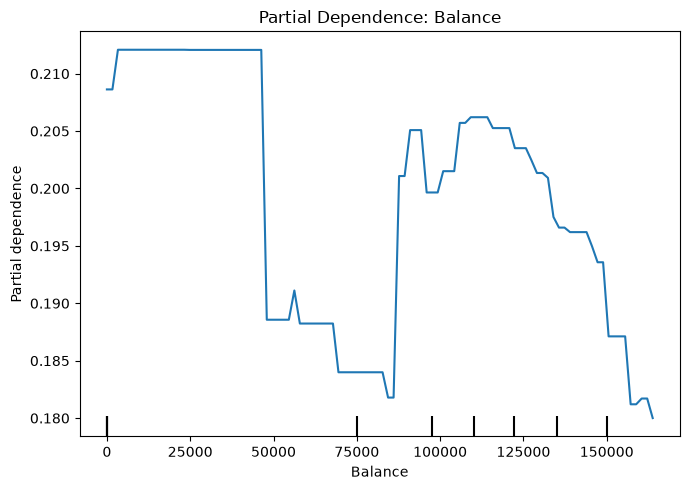

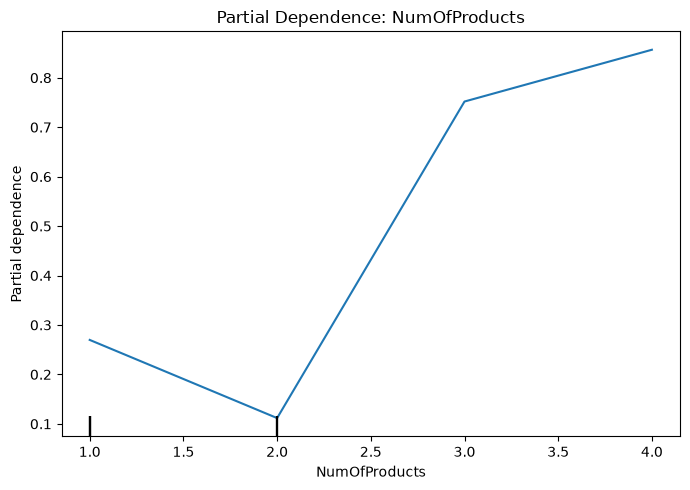

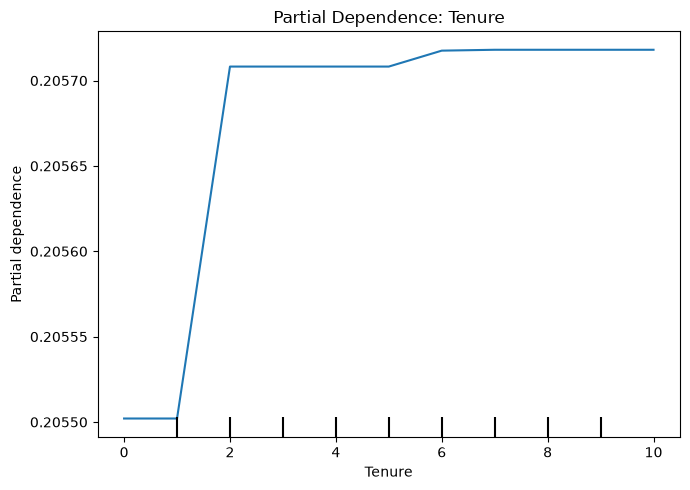

In [42]:
pdp_features = [
    "Year",
    "Age",
    "CreditScore",
    "Balance",
    "NumOfProducts",
    "Tenure"
]

X_test_pdp = X_test.copy()

for feature in pdp_features:
    X_test_pdp[feature] = X_test_pdp[feature].astype(float)

for feature in pdp_features:

    fig, ax = plt.subplots(figsize=(7, 5))

    PartialDependenceDisplay.from_estimator(
        final_model,
        X_test_pdp,
        [feature],
        ax=ax
    )

    plt.title("Partial Dependence: " + feature)
    plt.tight_layout()

    filename = "pdp_" + feature.lower() + ".png"

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [43]:
risk_predictions = pd.read_csv("risk_predictions.csv")

print(risk_predictions.head())
print("\nColumns:")
print(risk_predictions.columns.tolist())

   Year  CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0  2025          585    France    Male   36       7       0.00              2   
1  2025          525   Germany    Male   33       4  131023.76              2   
2  2025          557     Spain  Female   40       4       0.00              2   
3  2025          639     Spain    Male   34       5  139393.19              2   
4  2025          640     Spain  Female   34       3   77826.80              1   

   HasCrCard  IsActiveMember  EstimatedSalary  BalanceSalaryRatio  \
0          1               0         94283.09            0.000000   
1          0               0         55072.93            2.379052   
2          0               1        105433.53            0.000000   
3          0               0         33950.08            4.105707   
4          1               1        168544.85            0.461754   

   ProductDensity  EngagementProductInteraction  AgeTenureInteraction  \
0        0.250000        

In [44]:
print(
    risk_predictions["RiskCategory"].value_counts()
)

RiskCategory
Low          1575
Moderate      241
Very High     102
High           82
Name: count, dtype: int64


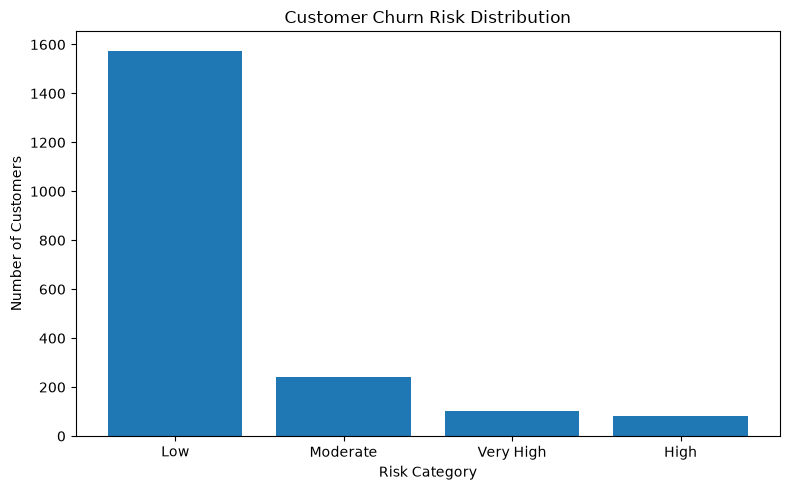

In [45]:
risk_counts = risk_predictions["RiskCategory"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Risk Distribution")

plt.tight_layout()
plt.show()

In [47]:
risk_summary = (
    risk_predictions
    .groupby("RiskCategory")
    .agg(
        Customers=("RiskCategory", "count"),
        AverageProbability=("ChurnProbability", "mean"),
        AverageRiskScore=("RiskScore", "mean")
    )
    .reset_index()
)

print(risk_summary)

  RiskCategory  Customers  AverageProbability  AverageRiskScore
0         High         82            0.703803         70.380295
1          Low       1575            0.100578         10.057802
2     Moderate        241            0.428676         42.867623
3    Very High        102            0.900856         90.085558


In [48]:
risk_summary.to_csv(
    "risk_category_summary.csv",
    index=False
)

print("Risk category summary saved.")

Risk category summary saved.


In [50]:
churn_by_risk = (
    risk_predictions
    .groupby("RiskCategory")["ActualExited"]
    .mean()
    .reset_index()
)

churn_by_risk["ActualChurnRate"] = (
    churn_by_risk["ActualExited"] * 100
)

print(churn_by_risk)

  RiskCategory  ActualExited  ActualChurnRate
0         High      0.792683        79.268293
1          Low      0.090794         9.079365
2     Moderate      0.435685        43.568465
3    Very High      0.921569        92.156863


In [51]:
risk_distribution = (
    risk_predictions["RiskCategory"]
    .value_counts()
    .reindex(["Low", "Moderate", "High", "Very High"], fill_value=0)
)

print(risk_distribution)

RiskCategory
Low          1575
Moderate      241
High           82
Very High     102
Name: count, dtype: int64


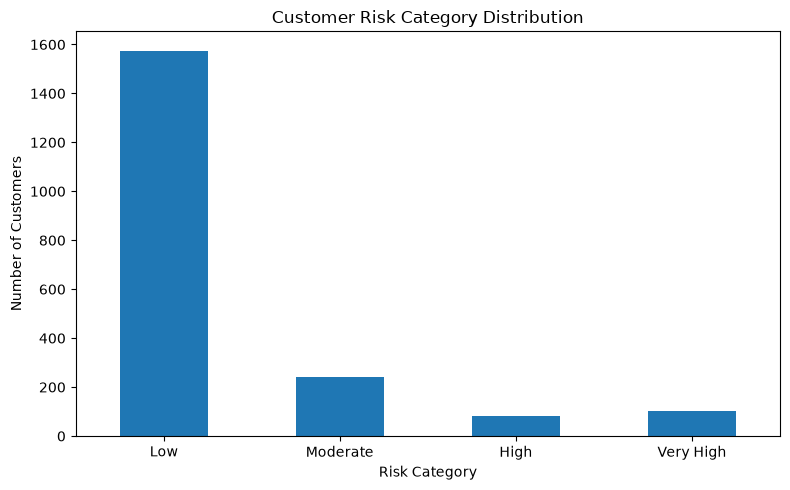

In [52]:
plt.figure(figsize=(8, 5))

risk_distribution.plot(kind="bar")

plt.title("Customer Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
risk_summary = (
    risk_predictions
    .groupby("RiskCategory")
    .agg(
        Customers=("RiskCategory", "count"),
        AverageProbability=("ChurnProbability", "mean"),
        AverageRiskScore=("RiskScore", "mean"),
        ActualChurnRate=("ActualExited", "mean")
    )
    .reset_index()
)

risk_summary["AverageProbability"] = (
    risk_summary["AverageProbability"] * 100
)

risk_summary["ActualChurnRate"] = (
    risk_summary["ActualChurnRate"] * 100
)

risk_summary = risk_summary[
    ["RiskCategory", "Customers", "AverageProbability",
     "AverageRiskScore", "ActualChurnRate"]
]

print(risk_summary)

  RiskCategory  Customers  AverageProbability  AverageRiskScore  \
0         High         82           70.380295         70.380295   
1          Low       1575           10.057802         10.057802   
2     Moderate        241           42.867623         42.867623   
3    Very High        102           90.085558         90.085558   

   ActualChurnRate  
0        79.268293  
1         9.079365  
2        43.568465  
3        92.156863  


In [55]:
risk_summary.to_csv(
    "risk_category_summary.csv",
    index=False
)

print("Risk category summary saved.")

Risk category summary saved.


In [56]:
churn_by_risk = (
    risk_predictions
    .groupby("RiskCategory")["ActualExited"]
    .mean()
    .reindex(["Low", "Moderate", "High", "Very High"])
)

churn_by_risk = churn_by_risk * 100

print(churn_by_risk)

RiskCategory
Low           9.079365
Moderate     43.568465
High         79.268293
Very High    92.156863
Name: ActualExited, dtype: float64


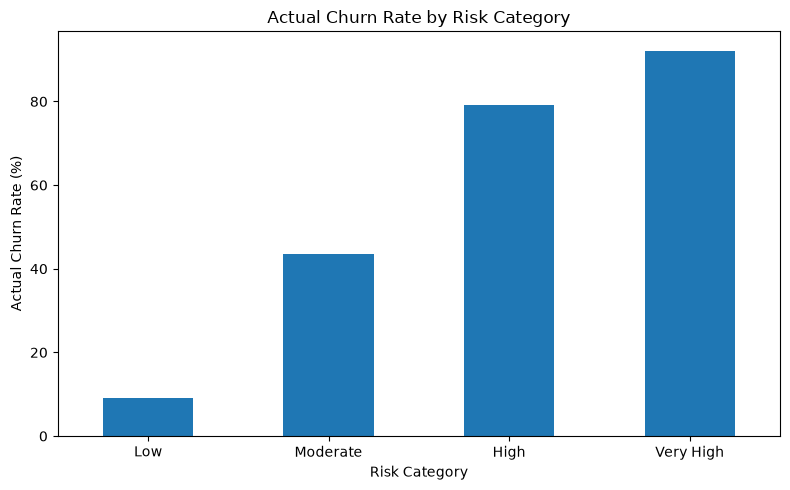

In [57]:
plt.figure(figsize=(8, 5))

churn_by_risk.plot(kind="bar")

plt.title("Actual Churn Rate by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Actual Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

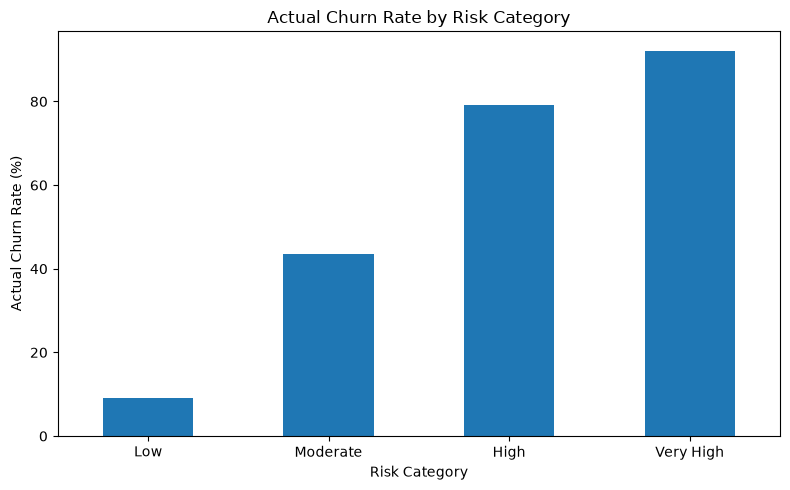

In [58]:
plt.figure(figsize=(8, 5))

churn_by_risk.plot(kind="bar")

plt.title("Actual Churn Rate by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Actual Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:
false_positives = risk_predictions[
    (risk_predictions["ActualExited"] == 0) &
    (risk_predictions["PredictedExited"] == 1)
]

false_negatives = risk_predictions[
    (risk_predictions["ActualExited"] == 1) &
    (risk_predictions["PredictedExited"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 55
False Negatives: 210


In [60]:
error_summary = pd.DataFrame({
    "Metric": [
        "False Positives",
        "False Negatives"
    ],
    "Count": [
        len(false_positives),
        len(false_negatives)
    ]
})

print(error_summary)

            Metric  Count
0  False Positives     55
1  False Negatives    210


In [61]:
error_summary.to_csv(
    "error_summary.csv",
    index=False
)

print("Error summary saved.")

Error summary saved.


In [62]:
customer_index = 0

customer = X_test.iloc[[customer_index]]

print("Customer details:")
display(customer)

Customer details:


,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction
0,2025,585,France,Male,36,7,0.0,2,1,0,94283.09,0.0,0.25,0,252


In [63]:
customer_probability = final_model.predict_proba(customer)[0][1]

customer_risk_score = customer_probability * 100

print("Churn Probability:", round(customer_probability, 4))
print("Risk Score:", round(customer_risk_score, 2))

Churn Probability: 0.0233
Risk Score: 2.33


In [64]:
def get_risk_category(score):
    if score < 30:
        return "Low"
    elif score < 60:
        return "Moderate"
    elif score < 80:
        return "High"
    else:
        return "Very High"


customer_risk_category = get_risk_category(customer_risk_score)

print("Risk Category:", customer_risk_category)

Risk Category: Low


In [65]:
customer_result = pd.DataFrame({
    "ChurnProbability": [customer_probability],
    "RiskScore": [customer_risk_score],
    "RiskCategory": [customer_risk_category]
})

print(customer_result)

   ChurnProbability  RiskScore RiskCategory
0          0.023345   2.334518          Low


In [66]:
customer_processed = preprocessor.transform(customer)

print("Processed customer shape:", customer_processed.shape)

Processed customer shape: (1, 18)


In [67]:
customer_shap = explainer(customer_processed)

print("SHAP explanation generated.")

SHAP explanation generated.


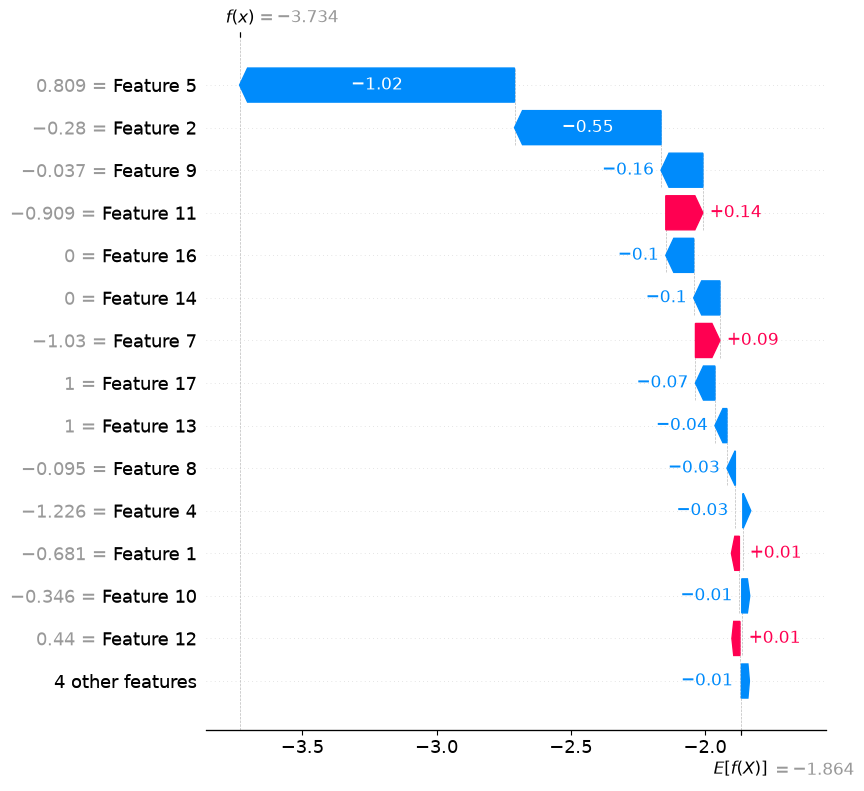

In [68]:
shap.plots.waterfall(
    customer_shap[0],
    max_display=15
)

In [69]:
customer_shap_values = customer_shap.values[0]

customer_shap_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAPValue": customer_shap_values
})

customer_shap_df["AbsoluteSHAP"] = (
    customer_shap_df["SHAPValue"].abs()
)

customer_shap_df = customer_shap_df.sort_values(
    "AbsoluteSHAP",
    ascending=False
)

print(customer_shap_df.head(15))

                              Feature  SHAPValue  AbsoluteSHAP
5                  num__NumOfProducts  -1.024293      1.024293
2                            num__Age  -0.545801      0.545801
9             num__BalanceSalaryRatio  -0.155876      0.155876
11  num__EngagementProductInteraction   0.138096      0.138096
16                 cat__Gender_Female  -0.103920      0.103920
14             cat__Geography_Germany  -0.097779      0.097779
7                 num__IsActiveMember   0.091213      0.091213
17                   cat__Gender_Male  -0.072574      0.072574
13              cat__Geography_France  -0.044720      0.044720
8                num__EstimatedSalary  -0.031471      0.031471
4                        num__Balance  -0.027672      0.027672
1                    num__CreditScore   0.012716      0.012716
10                num__ProductDensity  -0.008741      0.008741
12          num__AgeTenureInteraction   0.006776      0.006776
6                      num__HasCrCard  -0.005435      0

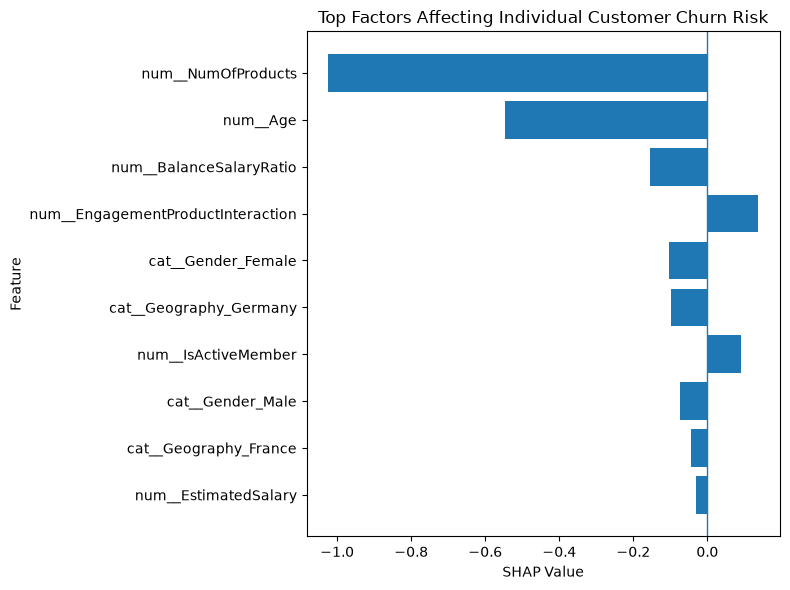

In [70]:
top_customer_features = customer_shap_df.head(10)

plt.figure(figsize=(8, 6))

plt.barh(
    top_customer_features["Feature"][::-1],
    top_customer_features["SHAPValue"][::-1]
)

plt.axvline(0, linewidth=1)

plt.title("Top Factors Affecting Individual Customer Churn Risk")
plt.xlabel("SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [71]:
customer_shap_df.to_csv(
    "individual_customer_shap.csv",
    index=False
)

print("Individual customer SHAP explanation saved.")

Individual customer SHAP explanation saved.


In [72]:
print("=" * 50)
print("INDIVIDUAL CUSTOMER RISK ASSESSMENT")
print("=" * 50)

print("Churn Probability :", round(customer_probability * 100, 2), "%")
print("Risk Score        :", round(customer_risk_score, 2))
print("Risk Category     :", customer_risk_category)

print("=" * 50)

INDIVIDUAL CUSTOMER RISK ASSESSMENT
Churn Probability : 2.33 %
Risk Score        : 2.33
Risk Category     : Low


In [73]:
print("Final Model:")
print(final_model.named_steps["model"])

Final Model:
GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)


In [75]:
print("=" * 60)
print("BANK CUSTOMER CHURN PROJECT - FINAL SUMMARY")
print("=" * 60)

# Calculate Test ROC-AUC from the saved predictions
from sklearn.metrics import roc_auc_score

test_roc_auc = roc_auc_score(
    risk_predictions["ActualExited"],
    risk_predictions["ChurnProbability"]
)

print("\nFinal Model:")
print(final_model.named_steps["model"])

print("\nTest ROC-AUC:")
print(round(test_roc_auc, 4))

print("\nRisk Categories:")
print(risk_predictions["RiskCategory"].value_counts())

print("\nFalse Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

print("\nIndividual Customer:")
print("Churn Probability:", round(customer_probability * 100, 2), "%")
print("Risk Score:", round(customer_risk_score, 2))
print("Risk Category:", customer_risk_category)

print("=" * 60)

BANK CUSTOMER CHURN PROJECT - FINAL SUMMARY

Final Model:
GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

Test ROC-AUC:
0.868

Risk Categories:
RiskCategory
Low          1575
Moderate      241
Very High     102
High           82
Name: count, dtype: int64

False Positives: 55
False Negatives: 210

Individual Customer:
Churn Probability: 2.33 %
Risk Score: 2.33
Risk Category: Low


In [76]:
roc_auc_score(
    risk_predictions["ActualExited"],
    risk_predictions["ChurnProbability"]
)

0.868015935812546

## Final Analysis

The bank customer churn prediction system was developed using multiple
machine learning classification models and a complete preprocessing pipeline.

The models evaluated include Logistic Regression, Decision Tree,
Random Forest, Gradient Boosting, and XGBoost.

Customer churn probability was converted into a 0-100 risk score and
classified into Low, Moderate, High, and Very High risk categories.

Feature importance, SHAP explanations, and Partial Dependence Plots were
used to understand the factors associated with model predictions.

The risk scoring framework can support customer-retention teams by helping
identify customers with higher predicted churn probability.

The predictions represent statistical patterns learned from historical data
and should be treated as decision-support information rather than causal
evidence.